In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

In [3]:
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
print("DATASET OVERVIEW")

print(f"\n Shape: {df.shape}")
print(f" Columns: {list(df.columns)}")
print(f"\n Data Types:\n{df.dtypes}")
print(f"\n Basic Statistics:")
df.describe()

DATASET OVERVIEW

 Shape: (303, 14)
 Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

 Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

 Basic Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
print("Missing Valuse Chack")

missing = df.isnull().sum()
print(f"\nMissing values per column:\n{missing}")
print(f"\nTotal missing values: {missing.sum()}")

if missing.sum() == 0:
    print("\n No missing values found!")
else:
    print("\n Missing values found — handling required")
    df = df.fillna(df.median())
    print(" Missing values filled with median")

Missing Valuse Chack

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0

 No missing values found!


Exploratory data analysis


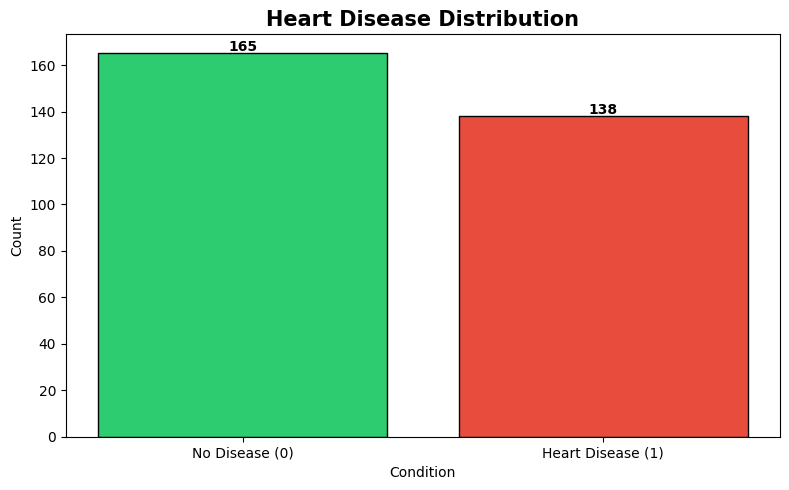


Target Distribution:
No Disease (0): 138 (45.5%)
Heart Disease (1): 165 (54.5%)


In [8]:
print("Exploratory data analysis")

# Target variable distribution
plt.figure(figsize=(8, 5))
target_counts = df['target'].value_counts()
plt.bar(['No Disease (0)', 'Heart Disease (1)'],
        target_counts.values,
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black')
plt.title('Heart Disease Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Count')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTarget Distribution:")
print(f"No Disease (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

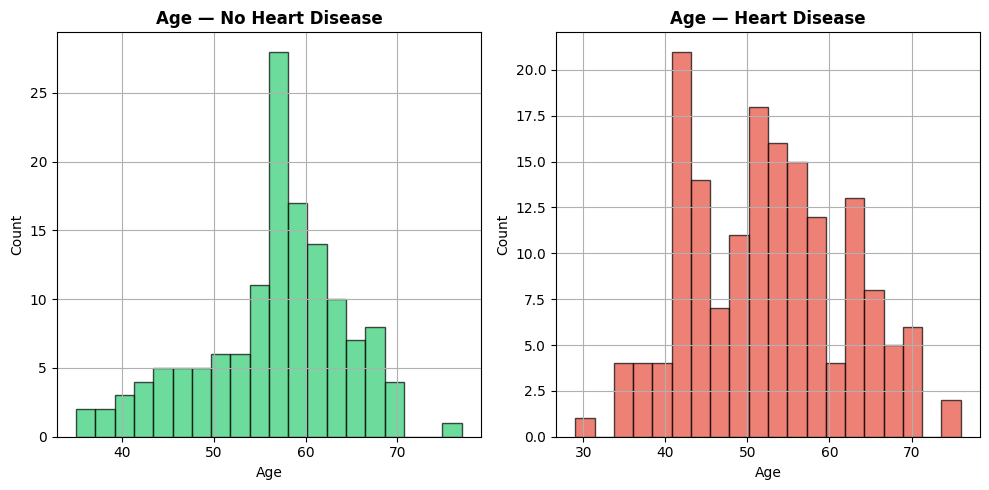

In [9]:
# Age Distribution by Target
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df[df['target'] == 0]['age'].hist(bins=20, color='#2ecc71',
                                   edgecolor='black', alpha=0.7)
plt.title('Age — No Heart Disease', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df[df['target'] == 1]['age'].hist(bins=20, color='#e74c3c',
                                   edgecolor='black', alpha=0.7)
plt.title('Age — Heart Disease', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

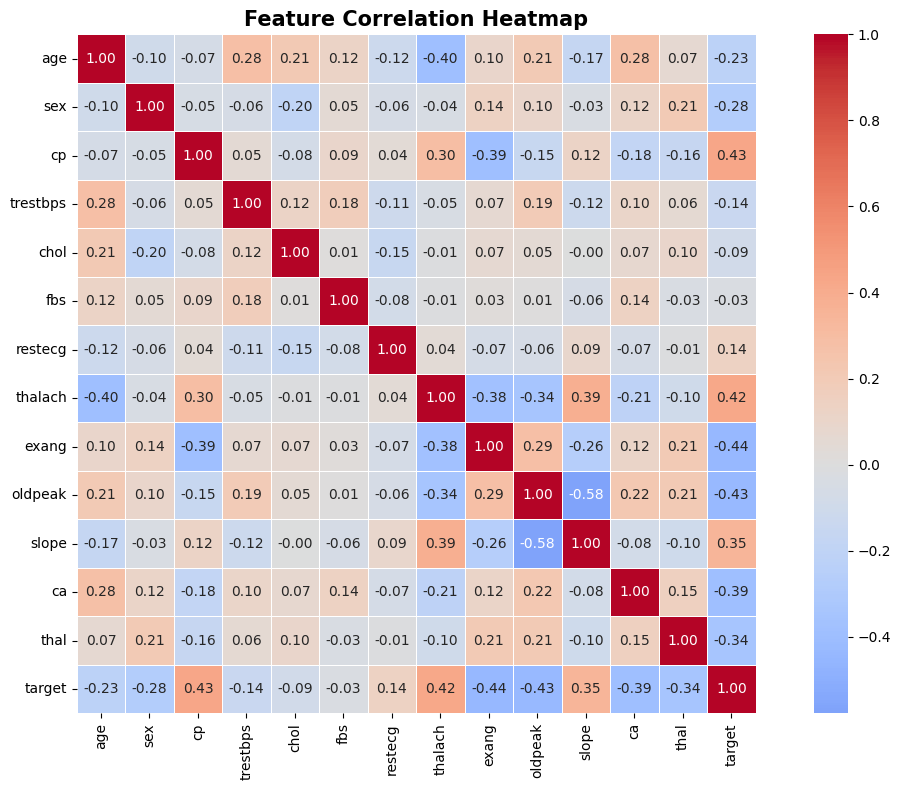

In [10]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

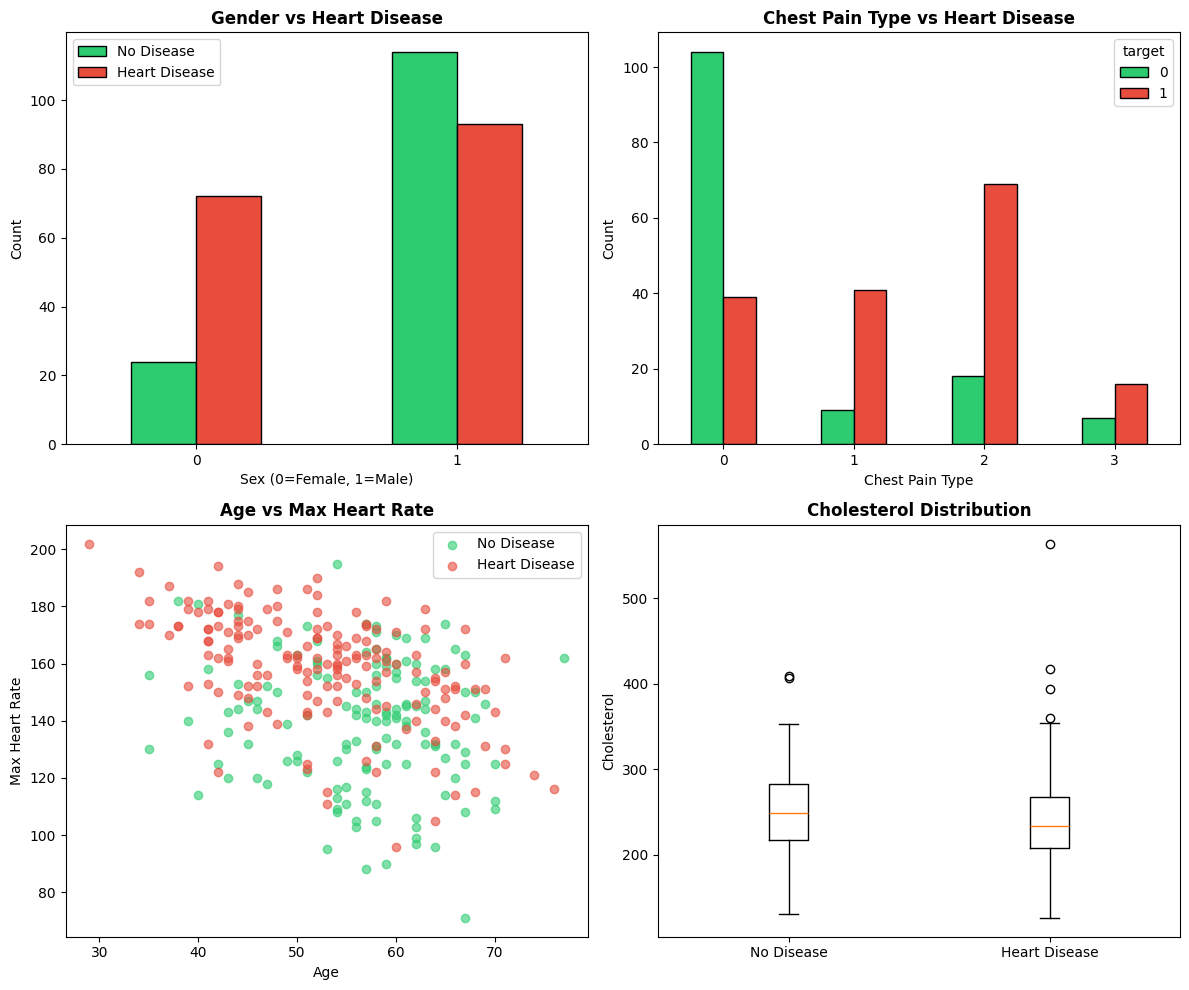

In [11]:
# Key Features Analysis
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gender vs Heart Disease
df.groupby(['sex', 'target']).size().unstack().plot(
    kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'],
    edgecolor='black')
axes[0,0].set_title('Gender vs Heart Disease', fontweight='bold')
axes[0,0].set_xlabel('Sex (0=Female, 1=Male)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(['No Disease', 'Heart Disease'])
axes[0,0].tick_params(rotation=0)

# Chest Pain Type vs Heart Disease
df.groupby(['cp', 'target']).size().unstack().plot(
    kind='bar', ax=axes[0,1], color=['#2ecc71', '#e74c3c'],
    edgecolor='black')
axes[0,1].set_title('Chest Pain Type vs Heart Disease', fontweight='bold')
axes[0,1].set_xlabel('Chest Pain Type')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(rotation=0)

# Max Heart Rate vs Target
axes[1,0].scatter(df[df['target']==0]['age'],
                   df[df['target']==0]['thalach'],
                   c='#2ecc71', alpha=0.6, label='No Disease')
axes[1,0].scatter(df[df['target']==1]['age'],
                   df[df['target']==1]['thalach'],
                   c='#e74c3c', alpha=0.6, label='Heart Disease')
axes[1,0].set_title('Age vs Max Heart Rate', fontweight='bold')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Max Heart Rate')
axes[1,0].legend()

# Cholesterol Distribution
axes[1,1].boxplot([df[df['target']==0]['chol'],
                    df[df['target']==1]['chol']],
                   labels=['No Disease', 'Heart Disease'])
axes[1,1].set_title('Cholesterol Distribution', fontweight='bold')
axes[1,1].set_ylabel('Cholesterol')

plt.tight_layout()
plt.show()

In [20]:
# Feature Engineering
print("Feature Engineering")
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain-Test Split:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied (StandardScaler)")

Feature Engineering
Features shape: (303, 13)
Target shape: (303,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Train-Test Split:
Training set: 242 samples
Testing set: 61 samples

Feature scaling applied (StandardScaler)


In [21]:
# Model Training
print("Model Training")

# Model 1: Logistic Regression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained!")

# Model 2: Random Forest Classifier
print("\nTraining Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained!")

Model Training

Training Logistic Regression...
Logistic Regression trained!

Training Random Forest Classifier...
Random Forest trained!


In [22]:
# Model Evauation
print("Model Evauation")

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f" {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred,
          target_names=['No Disease', 'Heart Disease']))
    return y_pred

# Evaluate both models
lr_pred = evaluate_model("Logistic Regression",
                          lr_model, X_test_scaled, y_test)
rf_pred = evaluate_model("Random Forest Classifier",
                          rf_model, X_test_scaled, y_test)

Model Evauation
 Logistic Regression
Accuracy:  0.8033
Precision: 0.7692
Recall:    0.9091
F1 Score:  0.8333

Classification Report:

               precision    recall  f1-score   support

   No Disease       0.86      0.68      0.76        28
Heart Disease       0.77      0.91      0.83        33

     accuracy                           0.80        61
    macro avg       0.82      0.79      0.80        61
 weighted avg       0.81      0.80      0.80        61

 Random Forest Classifier
Accuracy:  0.8361
Precision: 0.7805
Recall:    0.9697
F1 Score:  0.8649

Classification Report:

               precision    recall  f1-score   support

   No Disease       0.95      0.68      0.79        28
Heart Disease       0.78      0.97      0.86        33

     accuracy                           0.84        61
    macro avg       0.87      0.82      0.83        61
 weighted avg       0.86      0.84      0.83        61



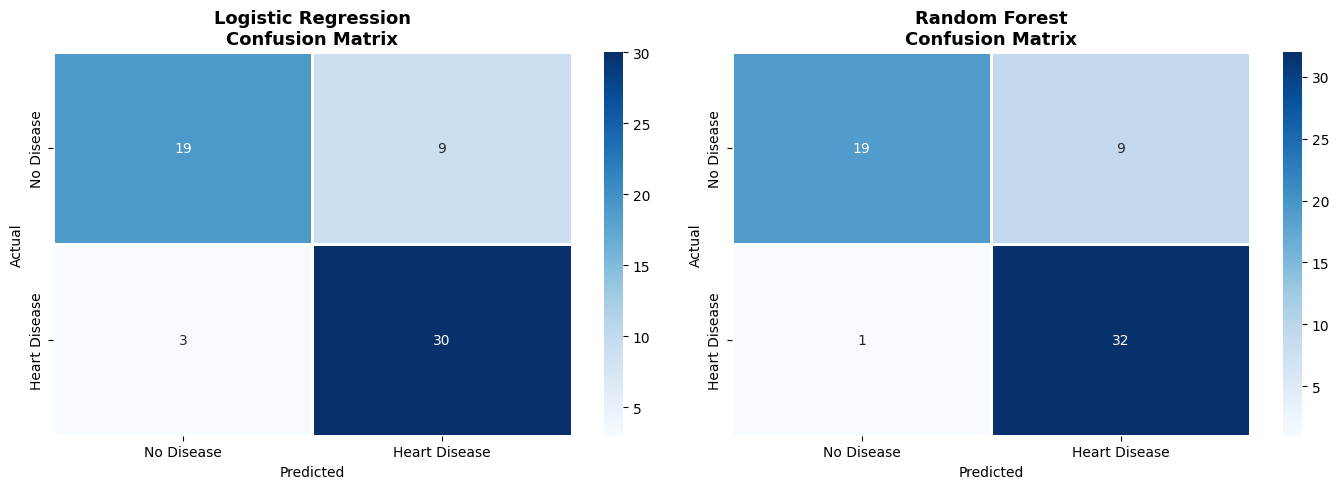

In [23]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [lr_pred, rf_pred],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                ax=ax, linewidths=1)
    ax.set_title(f'{title}\nConfusion Matrix',
                 fontweight='bold', fontsize=13)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Model Comparison
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8033     0.7692  0.9091    0.8333
Random Forest          0.8361     0.7805  0.9697    0.8649


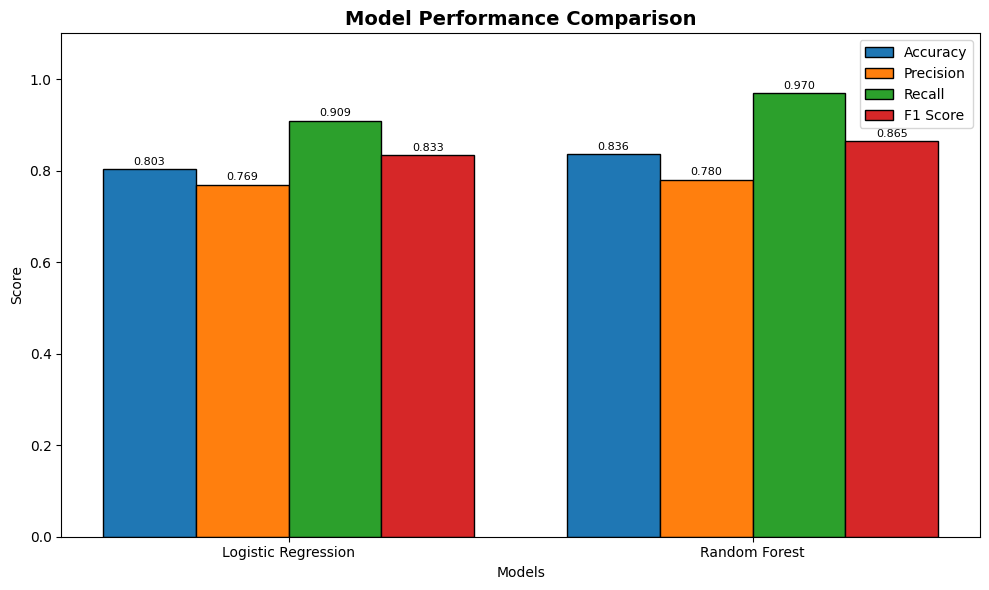


 Best Model: Random Forest
 Best Accuracy: 0.8361 (83.61%)


In [24]:
# Feature Importance (Random Forest)
print("Model Comparison")

models = ['Logistic Regression', 'Random Forest']
metrics = {
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
}

# Create comparison DataFrame
results_df = pd.DataFrame(metrics, index=models)
print(results_df.round(4))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
width = 0.2

for i, (metric, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i*width, values, width,
                  label=metric, edgecolor='black')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center',
                va='bottom', fontsize=8)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

# Best model
best_model = results_df['Accuracy'].idxmax()
best_acc = results_df['Accuracy'].max()
print(f"\n Best Model: {best_model}")
print(f" Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

Feature Importance — Random Forest


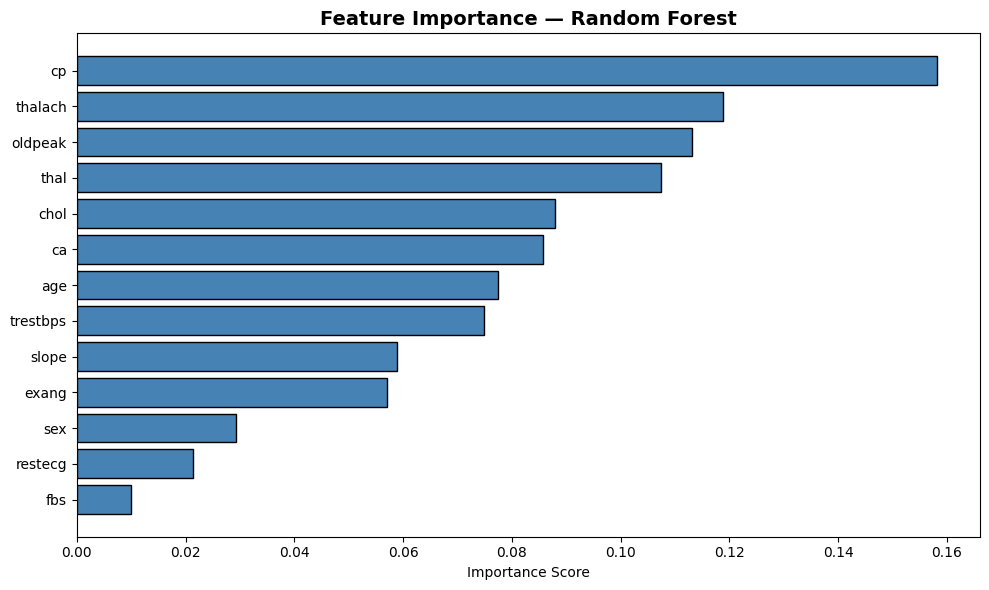


Top 5 Most Important Features:
    Feature  Importance
2        cp    0.158160
7   thalach    0.118753
9   oldpeak    0.113135
12     thal    0.107445
4      chol    0.087980


In [25]:
# Feature Importance (Random Forest)
print("Feature Importance — Random Forest")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

In [27]:
#Conclusion
print("CONCLUSION")

print("""
Project Summary: Heart Disease Prediction using ML

Dataset: UCI Heart Disease Dataset
   - 303 patients
   - 13 features (age, sex, chest pain type, etc.)
   - Binary classification (0: No Disease, 1: Heart Disease)

Models Trained:
   1. Logistic Regression
   2. Random Forest Classifier

Results:
""")
print(results_df.round(4))

print(f"""
Best Performing Model: {best_model}
   Accuracy: {best_acc*100:.2f}%

Key Insights:
   1. Chest pain type (cp) is the strongest predictor
   2. Max heart rate (thalach) inversely correlates with disease
   3. Age and sex are significant factors
   4. Random Forest generally outperforms Logistic Regression

This project demonstrates how ML can assist in early
   heart disease detection using routine medical data.
""")

CONCLUSION

Project Summary: Heart Disease Prediction using ML

Dataset: UCI Heart Disease Dataset
   - 303 patients
   - 13 features (age, sex, chest pain type, etc.)
   - Binary classification (0: No Disease, 1: Heart Disease)

Models Trained:
   1. Logistic Regression
   2. Random Forest Classifier

Results:

                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8033     0.7692  0.9091    0.8333
Random Forest          0.8361     0.7805  0.9697    0.8649

Best Performing Model: Random Forest
   Accuracy: 83.61%

Key Insights:
   1. Chest pain type (cp) is the strongest predictor
   2. Max heart rate (thalach) inversely correlates with disease
   3. Age and sex are significant factors
   4. Random Forest generally outperforms Logistic Regression

This project demonstrates how ML can assist in early
   heart disease detection using routine medical data.

